<a href="https://colab.research.google.com/github/MariamAkhtar/AngularJs1.7/blob/master/week7VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, Flatten, Reshape, Layer
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess MNIST data
(x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()
#(x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 28, 28, 1))


# -----------------------------
# Network parameters
# -----------------------------
input_shape = (28, 28, 1)
latent_dim = 2
intermediate_dim = 512
batch_size = 128

# -----------------------------
# Sampling Layer
# -----------------------------
class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# -----------------------------
# Build Encoder
# -----------------------------
def build_encoder():
    encoder_inputs = Input(shape=input_shape)
    x = Flatten()(encoder_inputs)
    x = Dense(intermediate_dim, activation='relu')(x)
    z_mean = Dense(latent_dim, name='z_mean')(x)
    z_log_var = Dense(latent_dim, name='z_log_var')(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
    return encoder

# -----------------------------
# Build Decoder
# -----------------------------
def build_decoder():
    decoder_inputs = Input(shape=(latent_dim,))
    x = Dense(intermediate_dim, activation='relu')(decoder_inputs)
    x = Dense(784, activation='sigmoid')(x)
    decoder_outputs = Reshape((28, 28, 1))(x)
    decoder = Model(decoder_inputs, decoder_outputs, name='decoder')
    return decoder

# -----------------------------
# Define VAE model
# -----------------------------
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name='loss')
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = tf.keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Flatten input and output
            flat_data = tf.reshape(data, (-1, 784))
            flat_reconstruction = tf.reshape(reconstruction, (-1, 784))

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(flat_data, flat_reconstruction),
                    axis=-1
                )
            )

            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

# Build VAE
def build_vae():
    encoder = build_encoder()
    decoder = build_decoder()
    vae = VAE(encoder, decoder)
    vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))
    return vae, encoder, decoder

# Generate digits
def generate_digits(decoder, n=10):
    z_sample = np.random.normal(size=(n, latent_dim))
    x_decoded = decoder.predict(z_sample, verbose=0)
    return x_decoded

# Plot generated digits
def plot_generated_digits(digits, title):
    plt.figure(figsize=(10, 2))
    for i in range(len(digits)):
        plt.subplot(1, len(digits), i + 1)
        plt.imshow(digits[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Plot training losses
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Total Loss')
    plt.plot(history.history['reconstruction_loss'], label='Reconstruction Loss')
    plt.plot(history.history['kl_loss'], label='KL Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot latent space
def plot_latent_space(encoder, x_data, y_data, title="Latent Space"):
    z_mean, _, _ = encoder.predict(x_data, batch_size=128, verbose=0)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        z_mean[:, 0],
        z_mean[:, 1],
        c=y_data,
        cmap='tab10',
        alpha=0.7,
        s=3
    )
    plt.colorbar(scatter)
    plt.xlabel("Latent Dimension 1")
    plt.ylabel("Latent Dimension 2")
    plt.title(title)
    plt.show()




Experiments: Train VAE for 5, 15, and 30 epochs


Training fresh VAE for 5 epochs
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - kl_loss: 5.6912 - loss: 52.9870 - reconstruction_loss: 47.2958
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - kl_loss: 3.5021 - loss: 36.3560 - reconstruction_loss: 32.8539
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - kl_loss: 2.6544 - loss: 34.1579 - reconstruction_loss: 31.5036
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - kl_loss: 2.2743 - loss: 33.1921 - reconstruction_loss: 30.9179
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - kl_loss: 2.0384 - loss: 32.5609 - reconstruction_loss: 30.5225


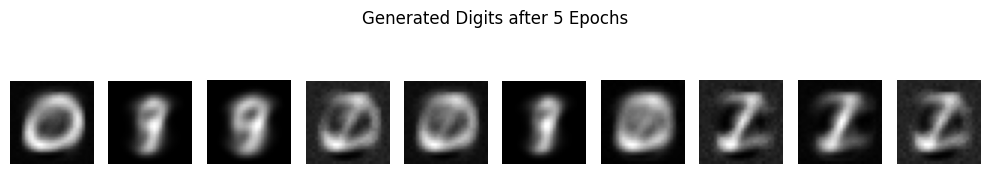

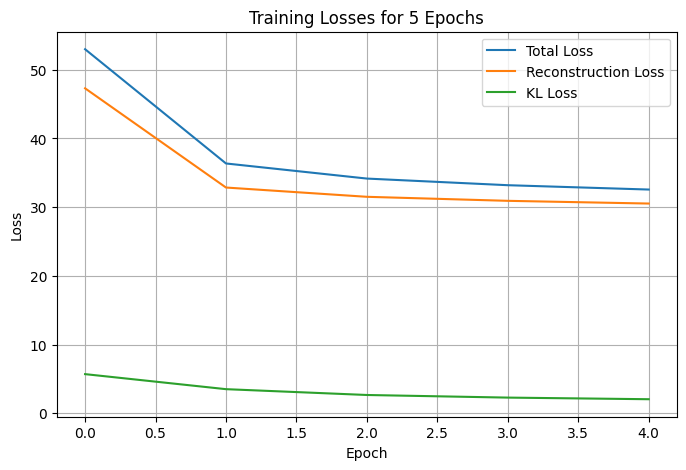

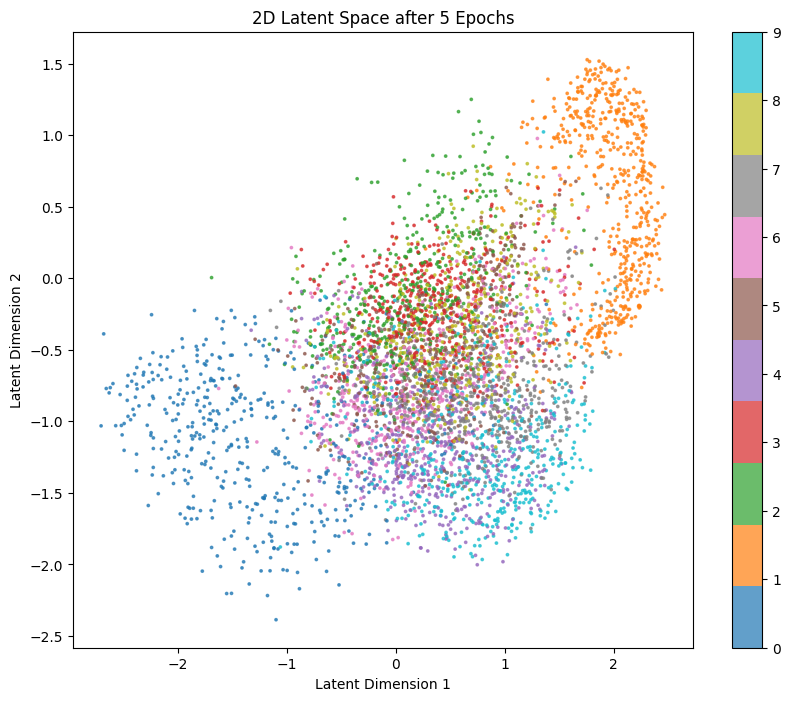


Training fresh VAE for 15 epochs
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - kl_loss: 5.4172 - loss: 53.8276 - reconstruction_loss: 48.4105
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - kl_loss: 3.4377 - loss: 36.4066 - reconstruction_loss: 32.9689
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - kl_loss: 2.5956 - loss: 34.2373 - reconstruction_loss: 31.6417
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 2.2579 - loss: 33.3084 - reconstruction_loss: 31.0506
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - kl_loss: 2.0442 - loss: 32.7153 - reconstruction_loss: 30.6711
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - kl_loss: 1.8672 - loss: 32.0362 - reconstruction_loss: 30.1690
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - kl_loss: 1.7788 - loss: 31.3759 - reconstruction_loss: 29.5971
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - kl_loss: 1.8068 - loss: 31.1054 - reconstruction_loss: 29.2987
Epoch 9/15
469

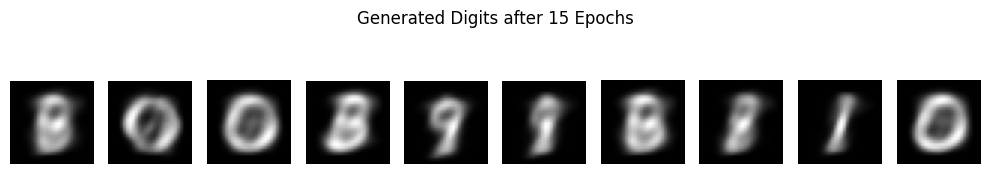

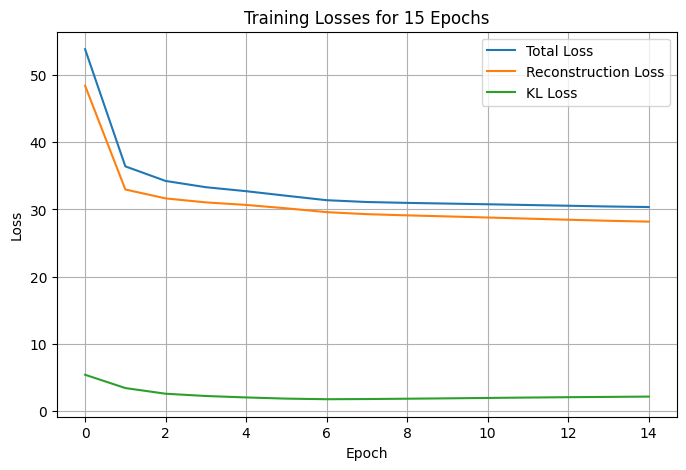

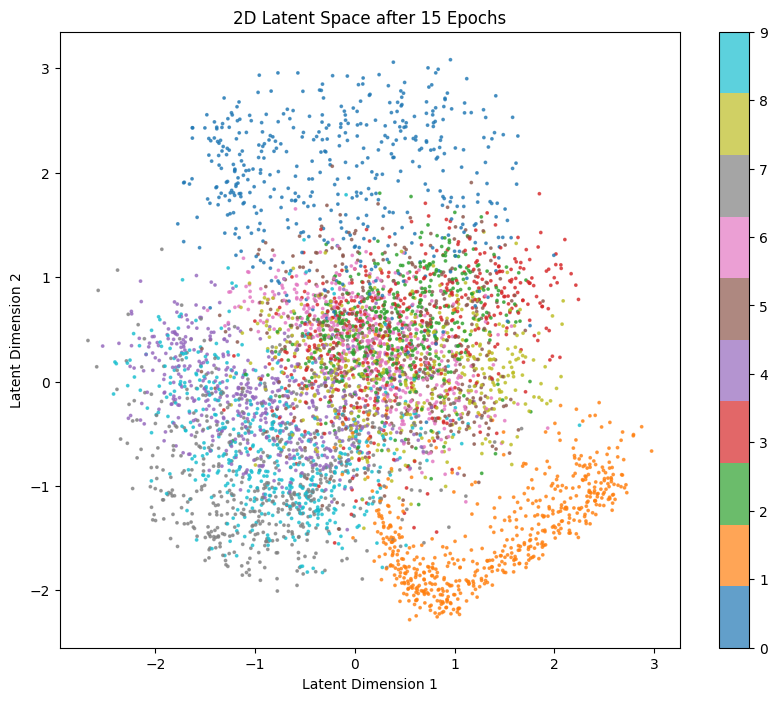


Training fresh VAE for 30 epochs
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - kl_loss: 5.2358 - loss: 53.6632 - reconstruction_loss: 48.4274
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - kl_loss: 3.4518 - loss: 36.7032 - reconstruction_loss: 33.2514
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 2.6766 - loss: 34.4610 - reconstruction_loss: 31.7844
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 2.3272 - loss: 33.4144 - reconstruction_loss: 31.0872
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 2.0954 - loss: 32.7774 - reconstruction_loss: 30.6820
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 1.9067 - loss: 32.1451 - reconstruction_loss: 30.2384
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 1.7998 - loss: 31.4625 - reconstruction_loss: 29.6627
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - kl_loss: 1.8164 - loss: 31.1037 - reconstruction_loss: 29.2873
Epoch 9/30
469

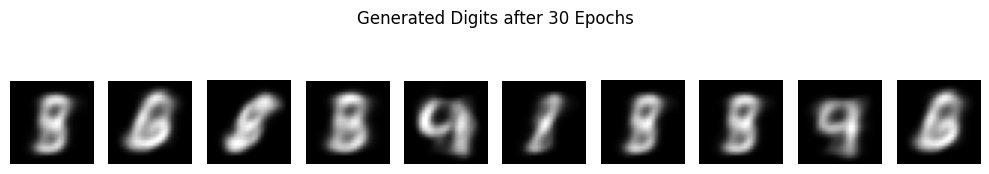

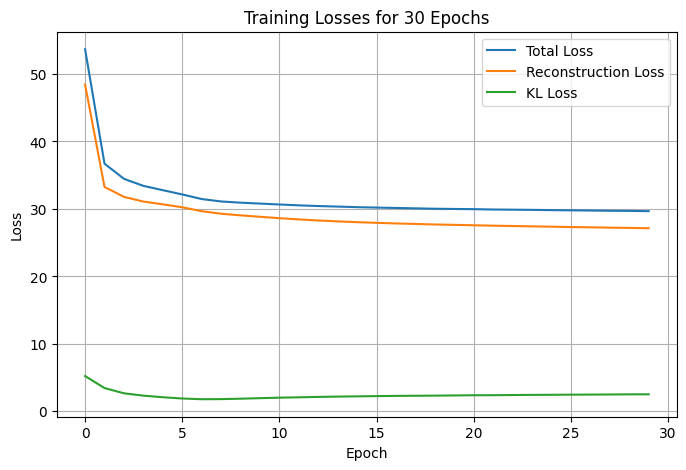

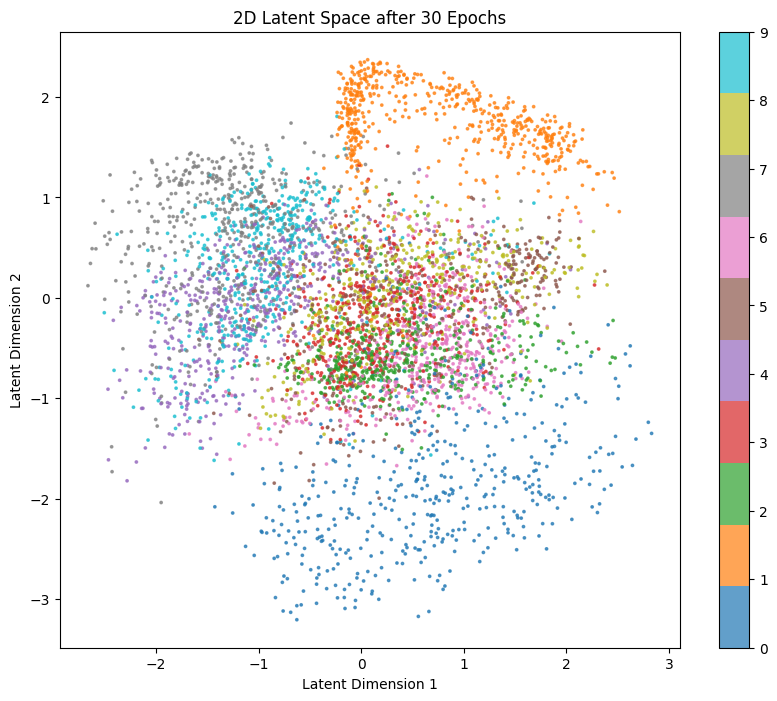

In [9]:

epoch_list = [5, 15, 30]
results = {}

# # Optional: Compare generated digits side by side
# plt.figure(figsize=(12, 5))
# for row, epochs in enumerate(epoch_list):
#     digits = results[epochs]["generated_digits"]
#     for col in range(10):
#         plt.subplot(len(epoch_list), 10, row * 10 + col + 1)
#         plt.imshow(digits[col].reshape(28, 28), cmap='gray')
#         plt.axis('off')
#         if col == 0:
#             plt.ylabel(f"{epochs} ep", fontsize=12)
# plt.suptitle("Comparison of Generated Digits after 5, 15, and 30 Epochs")
# plt.tight_layout()
# plt.show()

for epochs in epoch_list:
    print(f"\n==============================")
    print(f"Training fresh VAE for {epochs} epochs")
    print(f"==============================")

    vae, encoder, decoder = build_vae()

    history = vae.fit(
        x_train,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,
        verbose=1
    )

    # Generate new digits
    generated_digits = generate_digits(decoder, n=10)

    # Save results
    results[epochs] = {
        "vae": vae,
        "encoder": encoder,
        "decoder": decoder,
        "history": history,
        "generated_digits": generated_digits
    }

    # Plot generated digits
    plot_generated_digits(generated_digits, f"Generated Digits after {epochs} Epochs")

    # Plot training losses
    plot_history(history, f"Training Losses for {epochs} Epochs")

    # Plot latent space using a subset of data for speed
    plot_latent_space(
        encoder,
        x_train[:5000],
        y_train[:5000],
        title=f"2D Latent Space after {epochs} Epochs"
    )